<img src="https://www.metu.edu.tr/system/files/logo_orj/5/5.4.jpg" width="400" alt="Weights & Biases" />

# <font color='RED'>**📄 Surface Roughness Prediction In Additive Manufacturing**</font>

# Introduction

This notebook contains the exploratory data analysis of the experimental dataset, including descriptive statistics and visual examination of the relationships between surface roughness and key process variables.

Key Parameters:

The study focuses on 8 key printing parameters as model inputs ($X$): Layer Height, Extrusion Temperature, Outer Wall Speed, Infill Density, Wall Thickness, Bed Temperature, Fan Speed, and Surface Angle. The target output ($Y$) is the $R_a$ value.

## Please try installing the environment as described in the Readme file. If you want to run the code with your own Python environment, please ensure that the following libraries are installed.

In [ ]:
# pip install matplotlib numpy optuna pandas scikit-learn scipy shap tensorflow

# Exploratory Data Analysis (EDA)

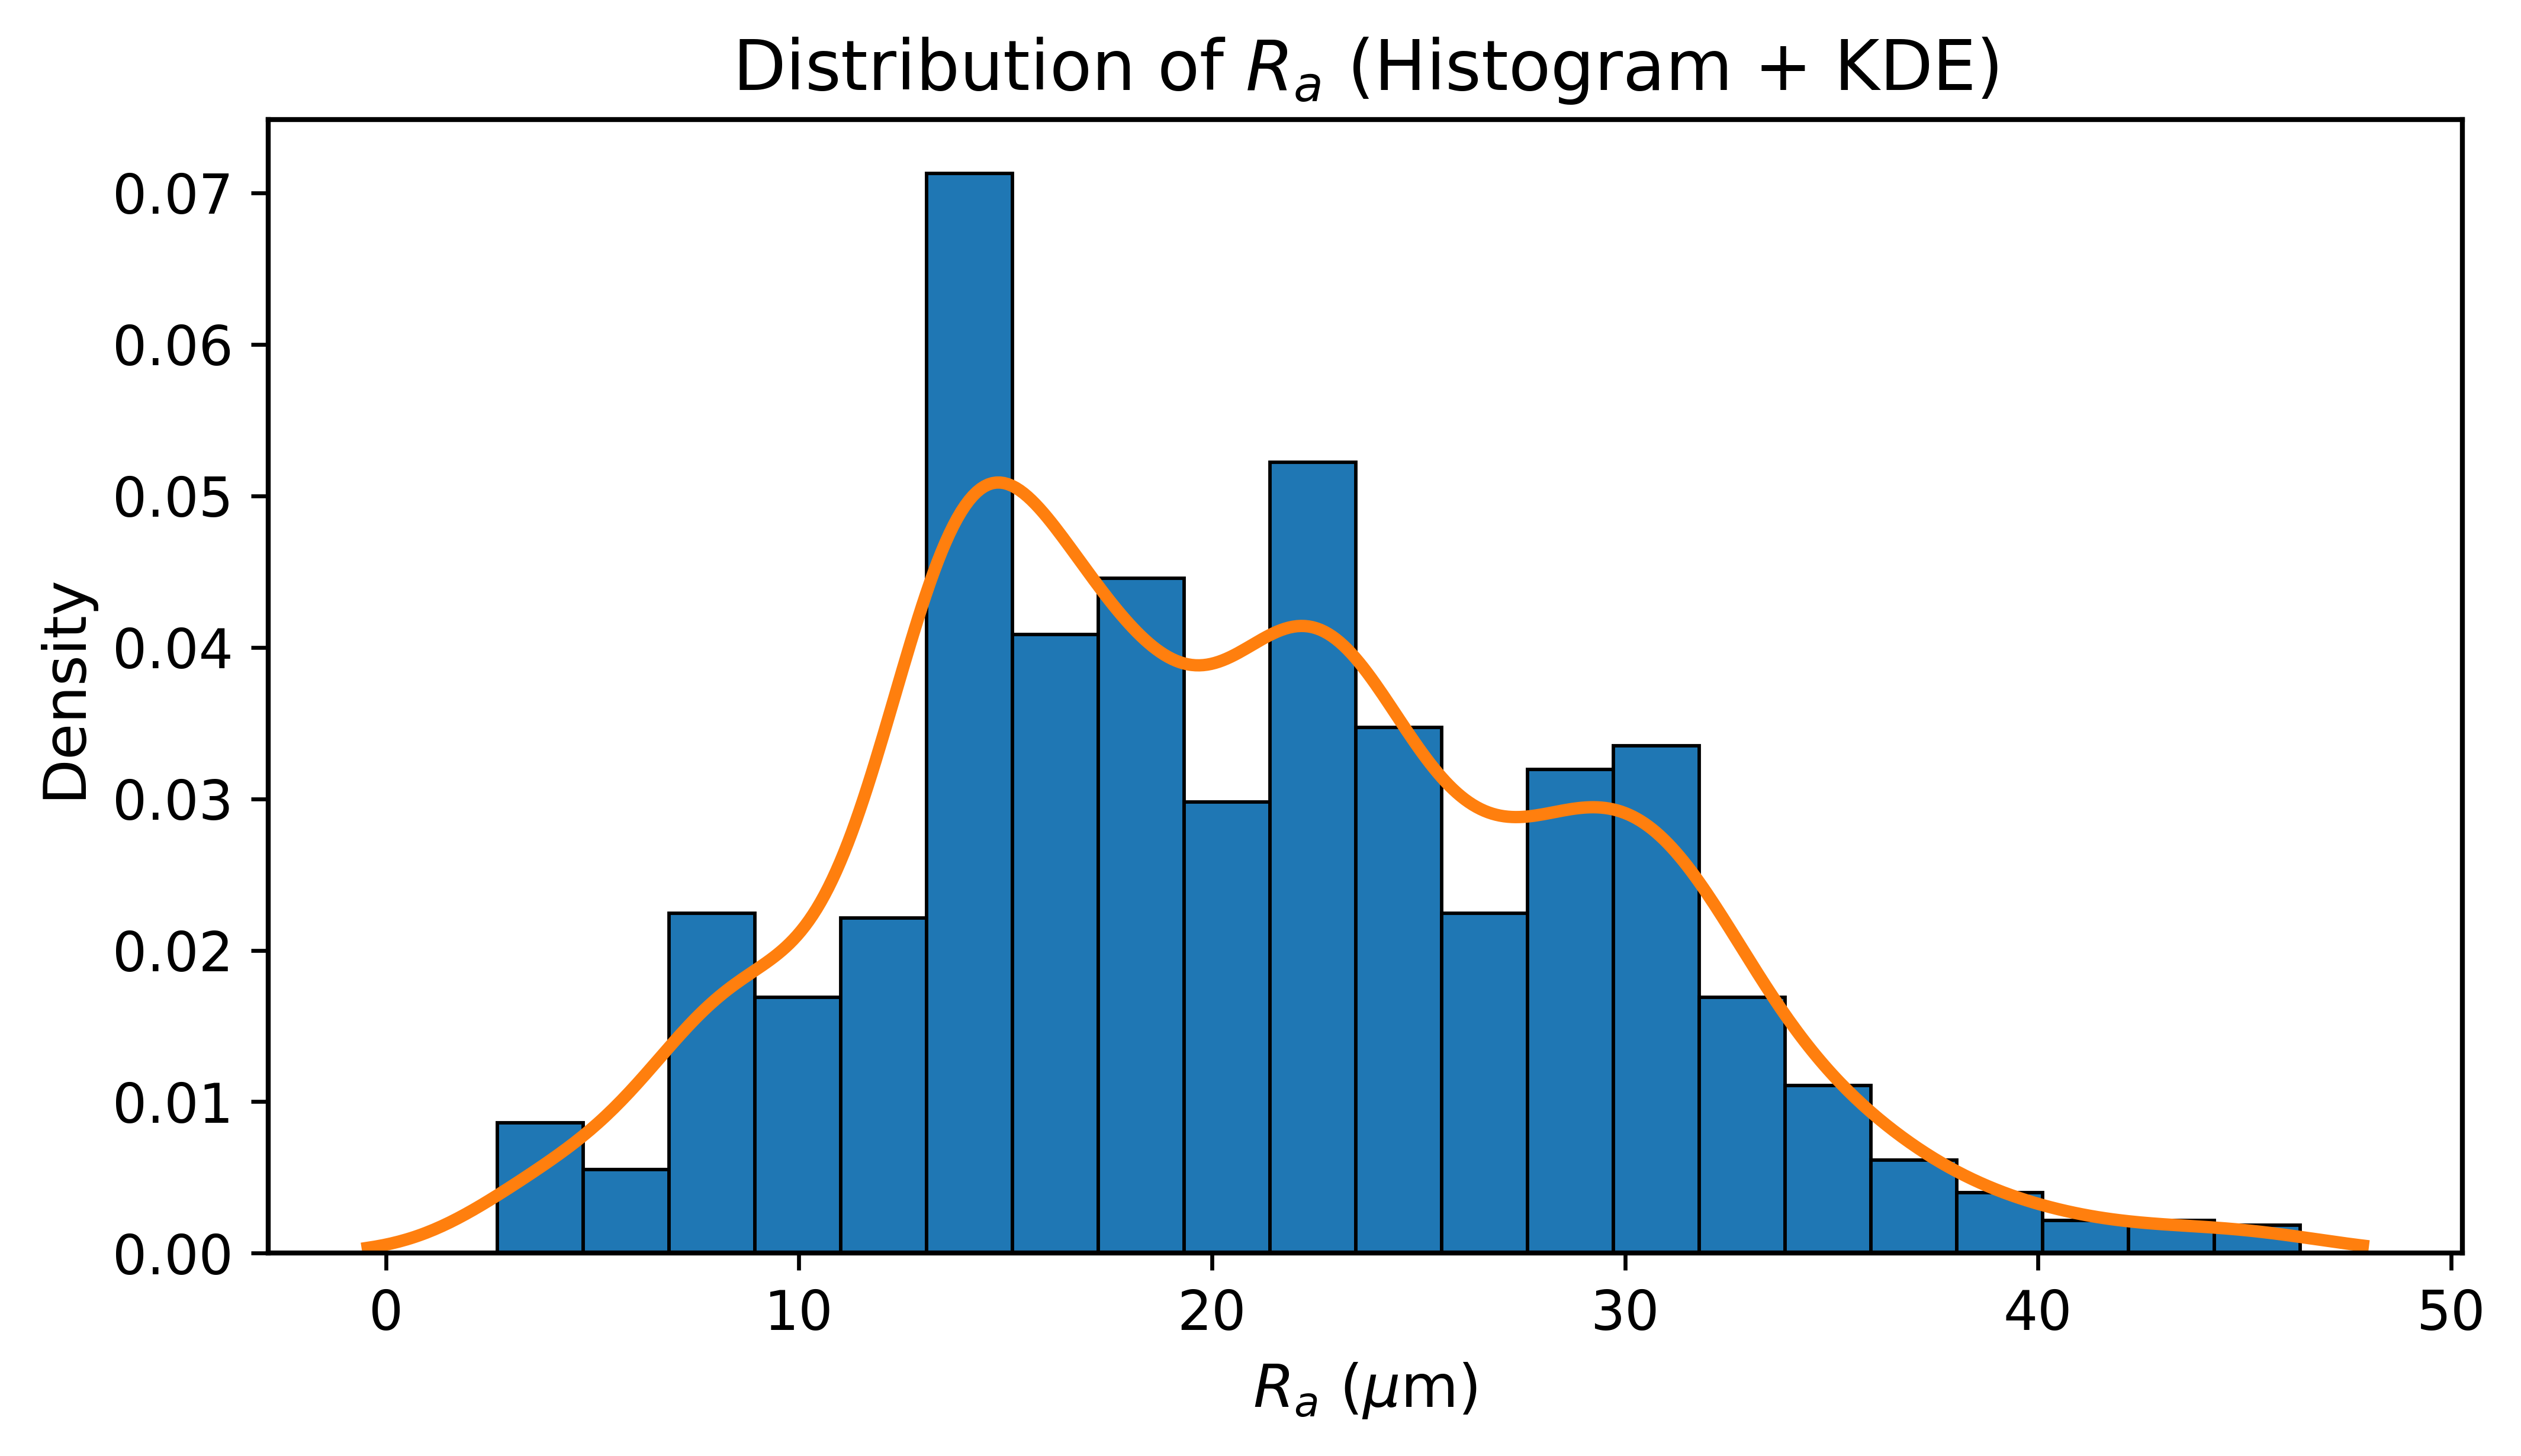

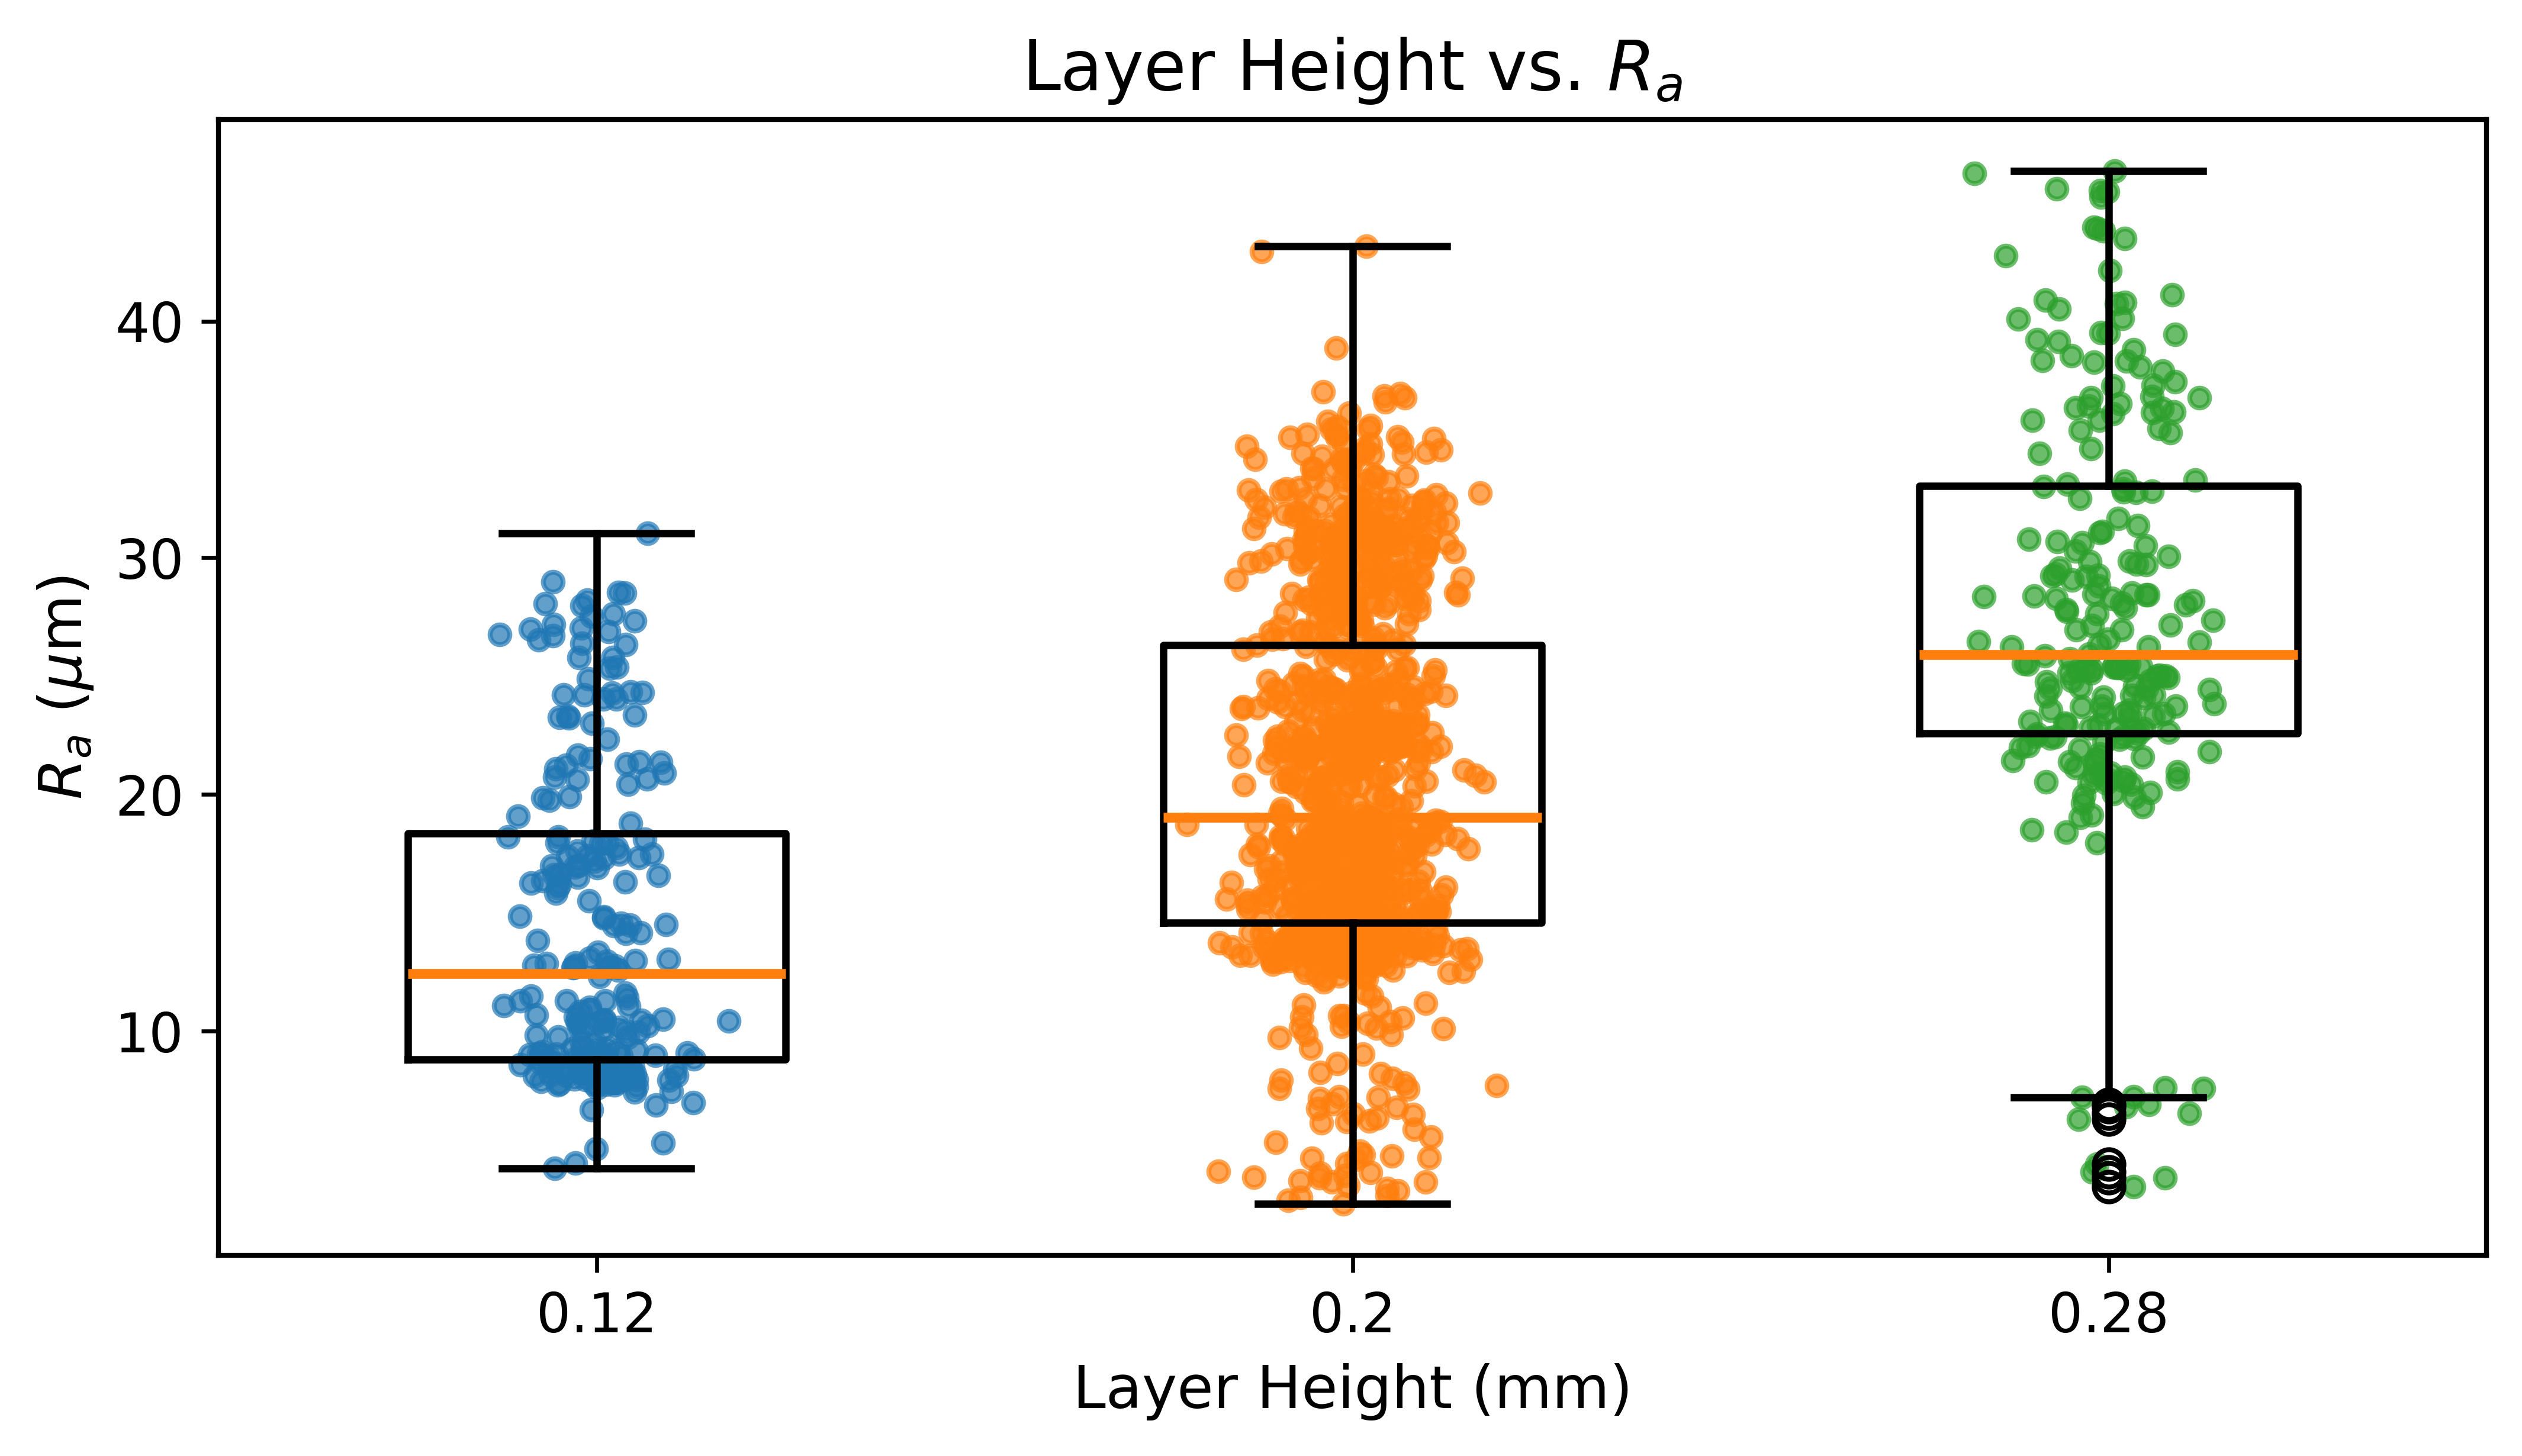

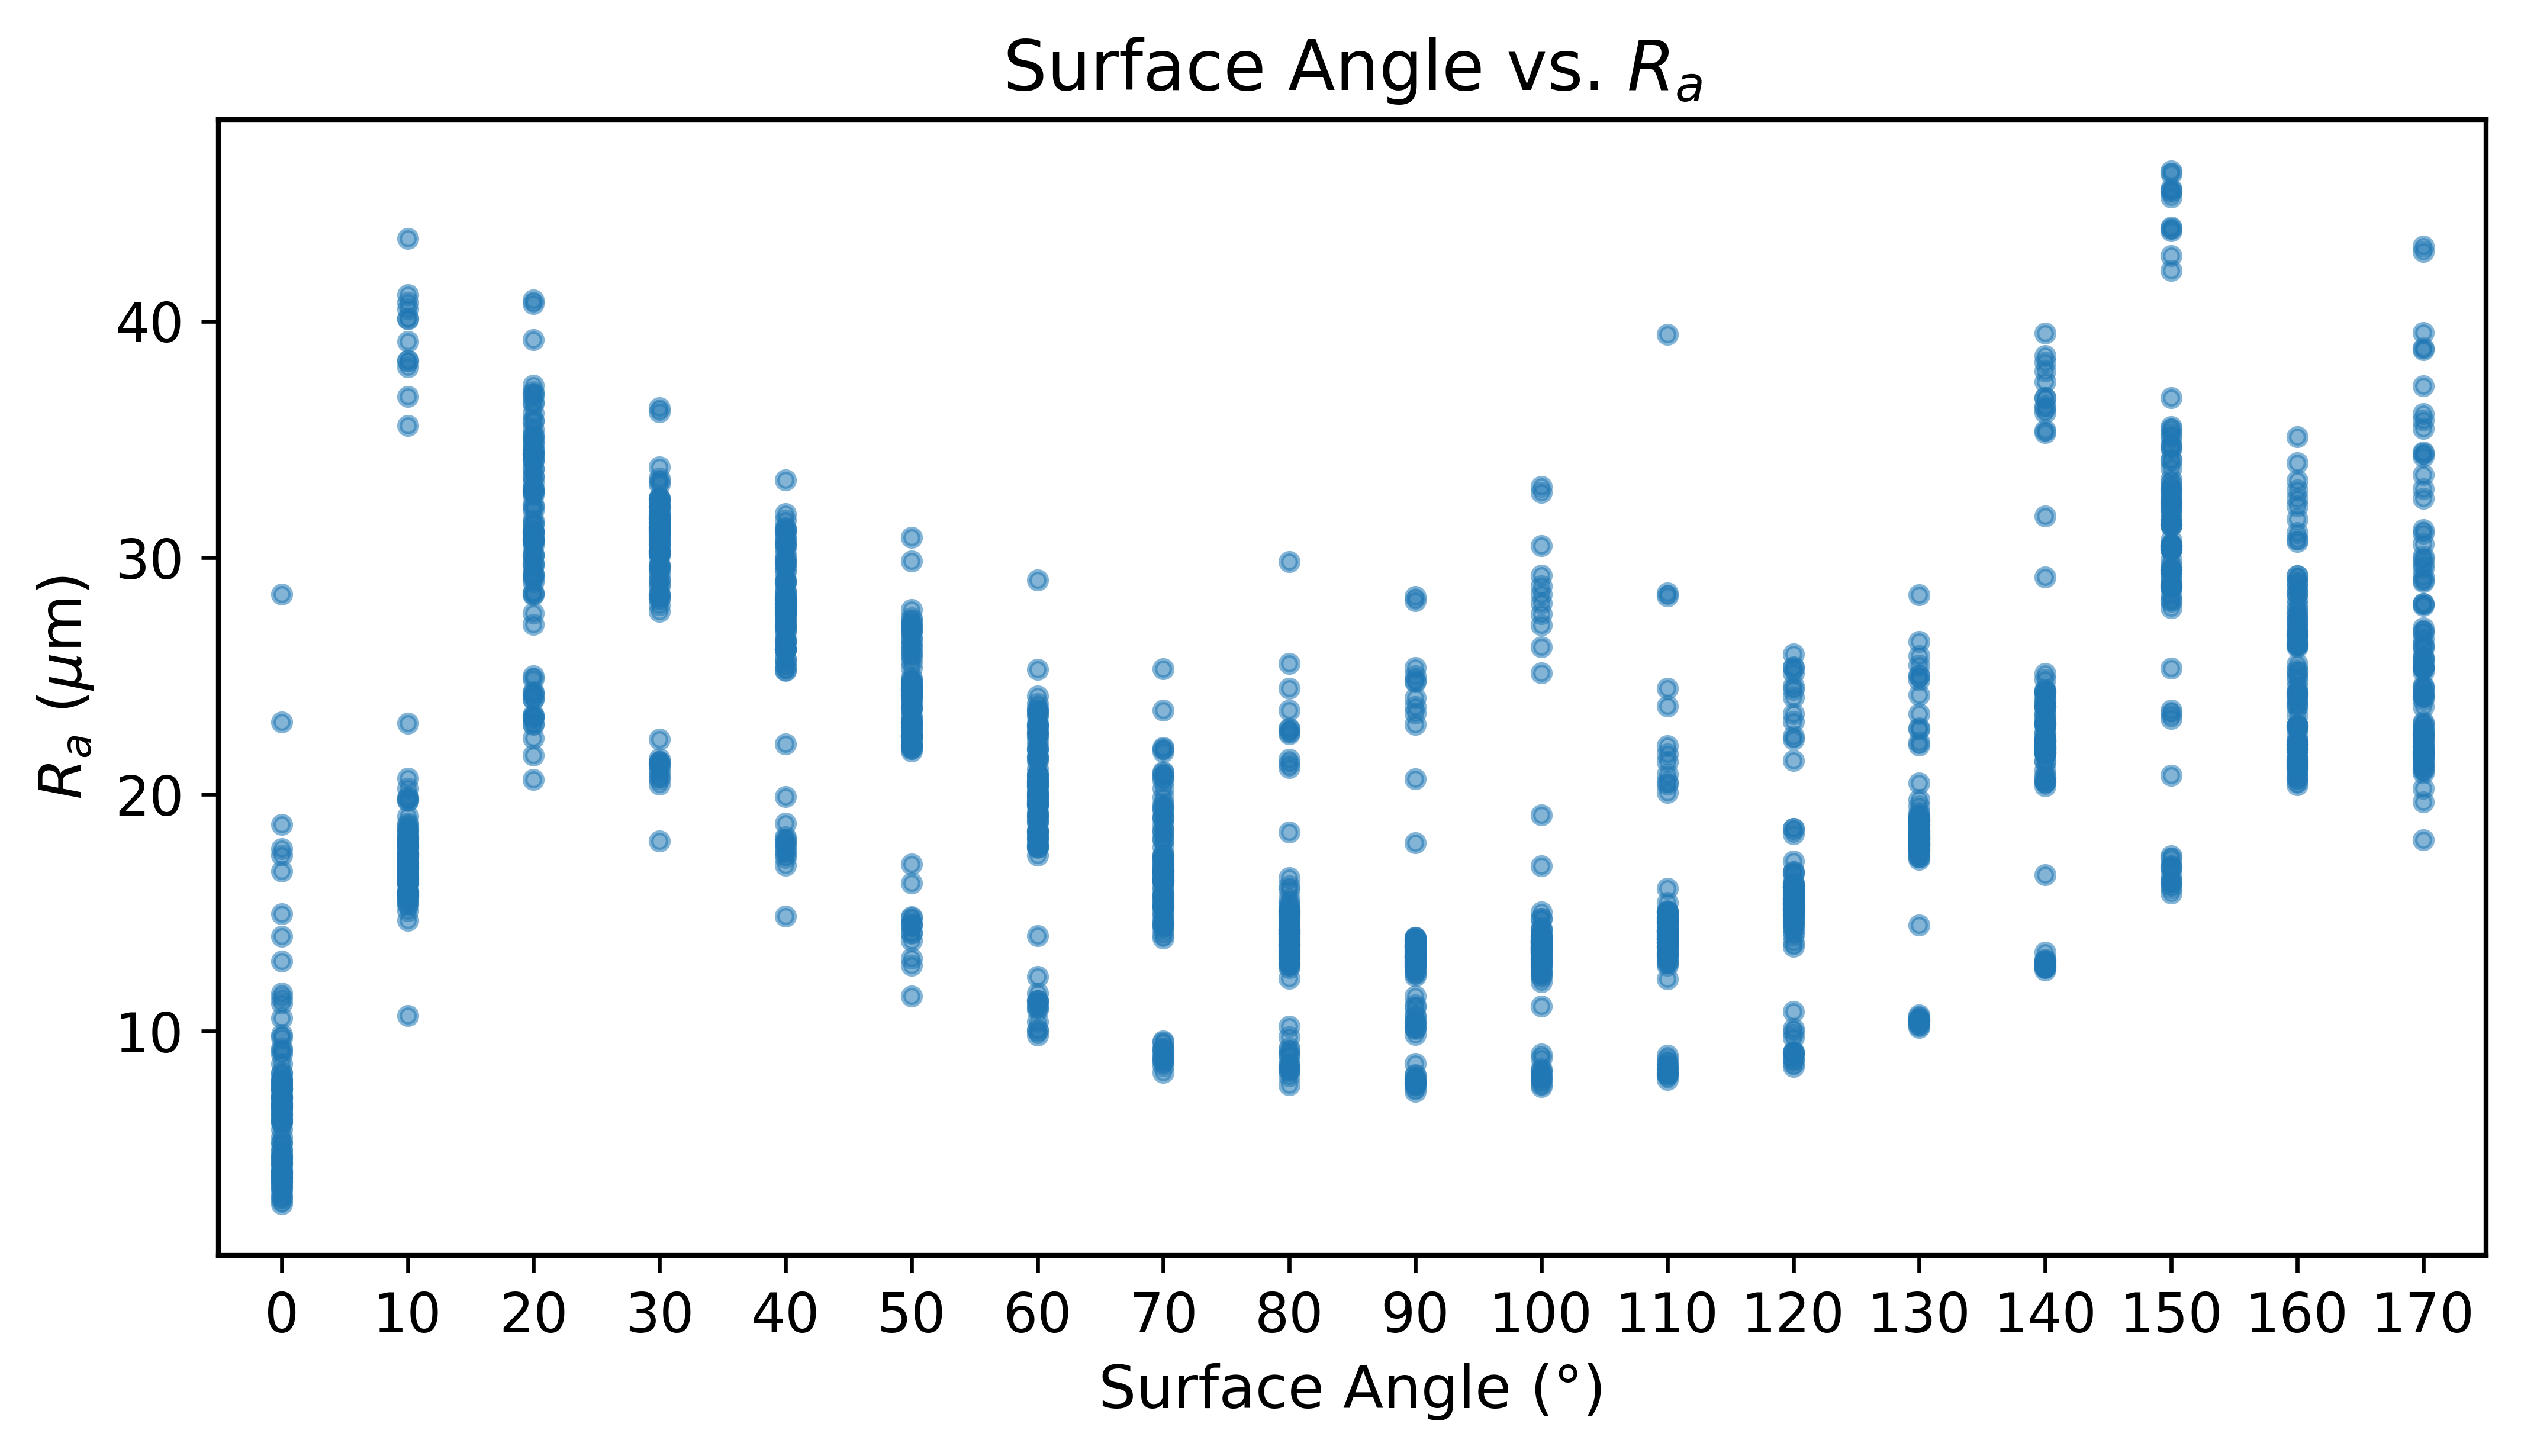

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,1566,87,Object-1,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Layer Height (mm),1566.0,NaN,NaN,NaN,0.2,0.042031,0.12,0.2,0.2,0.2,0.28
Extrusion Temp (°C),1566.0,NaN,NaN,NaN,200.0,5.253935,190.0,200.0,200.0,200.0,210.0
Outer Wall Speed (mm/s),1566.0,NaN,NaN,NaN,200.0,26.269675,150.0,200.0,200.0,200.0,250.0
Infill Density (%),1566.0,NaN,NaN,NaN,15.0,5.253935,5.0,15.0,15.0,15.0,25.0
Wall Thickness (mm),1566.0,NaN,NaN,NaN,0.42,0.031524,0.36,0.42,0.42,0.42,0.48
Bed Temp (°C),1566.0,NaN,NaN,NaN,60.0,2.626968,55.0,60.0,60.0,60.0,65.0
Fan Speed (%),1566.0,NaN,NaN,NaN,80.0,10.50787,60.0,80.0,80.0,80.0,100.0
Surface Angle (°),1566.0,NaN,NaN,NaN,85.0,51.897848,0.0,40.0,85.0,130.0,170.0
Ra,1566.0,NaN,NaN,NaN,20.624435,8.248649,2.694,14.211,20.1075,26.7565,46.34


,N,Mean,Std,Min,Q1,Median,Q3,Max,Skew,Kurtosis
Ra,1566,20.6244,8.2486,2.694,14.211,20.1075,26.7565,46.34,0.312,-0.3399
Surface Angle (°),1566,85.0000,51.8978,0.000,40.000,85.0000,130.0000,170.00,0.000,-1.2075
Layer Height (mm),1566,0.2000,0.0420,0.120,0.200,0.2000,0.2000,0.28,0.000,0.6308


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

DATA_PATH = Path("..") / "dataset" / "mahr_data.csv"
DPI = 600

FIG_W, FIG_H = 7.2, 4.2
TITLE_SIZE = 14
LABEL_SIZE = 12
TICK_SIZE = 11

COL_RA = "Ra"
COL_ANGLE = "Surface Angle (°)"
COL_LH = "Layer Height (mm)"

S_SCATTER_ANGLE = 12
ALPHA_ANGLE = 0.55

S_SCATTER_LH = 16
ALPHA_LH = 0.70
JITTER_STD = 0.06

SNAP_ANGLE_TO_10 = True
ANGLE_MIN, ANGLE_MAX = 0, 170
ANGLE_STEP = 10


def find_column(df: pd.DataFrame, desired: str):
    if desired in df.columns:
        return desired
    norm = lambda s: "".join(str(s).lower().split())
    desired_n = norm(desired)
    for c in df.columns:
        if norm(c) == desired_n:
            return c
    return None


def style_axes(ax):
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


def kde_1d(x, grid=None, bw="scott"):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return None, None
    kde = stats.gaussian_kde(x, bw_method=bw)
    if grid is None:
        xmin, xmax = np.percentile(x, [0.5, 99.5])
        pad = 0.10 * (xmax - xmin + 1e-9)
        grid = np.linspace(xmin - pad, xmax + pad, 512)
    dens = kde(grid)
    return grid, dens


def main():
    df = pd.read_csv(DATA_PATH)

    ra_col = find_column(df, COL_RA)
    angle_col = find_column(df, COL_ANGLE)
    lh_col = find_column(df, COL_LH)

    missing = [name for name, col in [
        (COL_RA, ra_col),
        (COL_ANGLE, angle_col),
        (COL_LH, lh_col),
    ] if col is None]

    if missing:
        raise ValueError(
            f"Missing expected columns.\n"
            f"Not found: {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

    df[ra_col] = pd.to_numeric(df[ra_col], errors="coerce")
    df[angle_col] = pd.to_numeric(df[angle_col], errors="coerce")
    df[lh_col] = pd.to_numeric(df[lh_col], errors="coerce")

    df_clean = df.dropna(subset=[ra_col]).copy()

    # All descriptive statistics as DataFrame
    desc = df_clean.describe(include="all").T

    # Key descriptive statistics as DataFrame
    key = df_clean[[ra_col, angle_col, lh_col]].copy()
    key_stats = pd.DataFrame({
        "N": key.count(),
        "Mean": key.mean(),
        "Std": key.std(ddof=1),
        "Min": key.min(),
        "Q1": key.quantile(0.25),
        "Median": key.median(),
        "Q3": key.quantile(0.75),
        "Max": key.max(),
        "Skew": key.skew(numeric_only=True),
        "Kurtosis": key.kurtosis(numeric_only=True),
    })

    desc = desc.round(4)
    key_stats = key_stats.round(4)

    # ---------------- Plot 1: Histogram + KDE ----------------
    ra = df_clean[ra_col].dropna().values.astype(float)

    fig1, ax1 = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)
    ax1.hist(ra, bins="auto", density=True, edgecolor="black", linewidth=0.7)

    grid, dens = kde_1d(ra)
    if grid is not None:
        ax1.plot(grid, dens, linewidth=2.5)

    ax1.set_title(r"Distribution of $R_a$ (Histogram + KDE)", fontsize=TITLE_SIZE)
    ax1.set_xlabel(r"$R_a$ ($\mu$m)", fontsize=LABEL_SIZE)
    ax1.set_ylabel("Density", fontsize=LABEL_SIZE)
    style_axes(ax1)
    fig1.tight_layout()
    plt.show()

    # ---------------- Plot 2: Layer Height vs Ra ----------------
    tmp_lh = df_clean.dropna(subset=[lh_col, ra_col]).copy()
    lh_levels = np.sort(tmp_lh[lh_col].unique())

    fig2, ax2 = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)
    data_by_level = [tmp_lh.loc[tmp_lh[lh_col] == lv, ra_col].values for lv in lh_levels]

    ax2.boxplot(
        data_by_level,
        positions=np.arange(len(lh_levels)),
        widths=0.5,
        patch_artist=False,
        medianprops=dict(linewidth=2.0),
        boxprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
    )

    rng = np.random.default_rng(42)
    for i, lv in enumerate(lh_levels):
        y = tmp_lh.loc[tmp_lh[lh_col] == lv, ra_col].values
        x = np.full_like(y, i, dtype=float) + rng.normal(0, JITTER_STD, size=len(y))
        ax2.scatter(x, y, s=S_SCATTER_LH, alpha=ALPHA_LH)

    ax2.set_xticks(np.arange(len(lh_levels)))
    ax2.set_xticklabels([f"{lv:g}" for lv in lh_levels], fontsize=TICK_SIZE)
    ax2.set_title(r"Layer Height vs. $R_a$", fontsize=TITLE_SIZE)
    ax2.set_xlabel("Layer Height (mm)", fontsize=LABEL_SIZE)
    ax2.set_ylabel(r"$R_a$ ($\mu$m)", fontsize=LABEL_SIZE)
    style_axes(ax2)
    fig2.tight_layout()
    plt.show()

    # ---------------- Plot 3: Surface Angle vs Ra ----------------
    tmp_ang = df_clean.dropna(subset=[angle_col, ra_col]).copy()

    if SNAP_ANGLE_TO_10:
        tmp_ang[angle_col] = (tmp_ang[angle_col] / ANGLE_STEP).round() * ANGLE_STEP

    tmp_ang = tmp_ang[
        (tmp_ang[angle_col] >= ANGLE_MIN) & (tmp_ang[angle_col] <= ANGLE_MAX)
    ].copy()

    angle_levels = np.arange(ANGLE_MIN, ANGLE_MAX + 1, ANGLE_STEP)

    fig3, ax3 = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)
    ax3.scatter(
        tmp_ang[angle_col].values,
        tmp_ang[ra_col].values,
        s=S_SCATTER_ANGLE,
        alpha=ALPHA_ANGLE
    )

    ax3.set_xticks(angle_levels)
    ax3.set_xlim(ANGLE_MIN - 5, ANGLE_MAX + 5)

    ax3.set_title(r"Surface Angle vs. $R_a$", fontsize=TITLE_SIZE)
    ax3.set_xlabel("Surface Angle (°)", fontsize=LABEL_SIZE)
    ax3.set_ylabel(r"$R_a$ ($\mu$m)", fontsize=LABEL_SIZE)
    style_axes(ax3)
    fig3.tight_layout()
    plt.show()

    # Return outputs as DataFrames
    return {
        "all_descriptive_statistics": desc,
        "key_descriptive_statistics": key_stats
    }


if __name__ == "__main__":
    results = main()

    all_stats_df = results["all_descriptive_statistics"]
    key_stats_df = results["key_descriptive_statistics"]

    display(all_stats_df)
    display(key_stats_df)